# Employee Attrition Prediction using Machine Learning

# import libraries

In [1]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier


# load dataset

In [2]:
data = pd.read_csv("C:/Users/DELL/Documents/ML/ai.csv")



In [3]:
data.head()


,employee_id,job_role,years_experience,education_level,country,industry,company_size,remote_work_type,team_size,salary_usd_k,...,ai_tools_used_per_day,hours_with_ai_assistance_daily,ai_replaces_my_tasks_pct,ai_adoption_stage,weekly_ai_upskilling_hrs,productivity_score,burnout_score,job_satisfaction_1_5,fear_of_ai_replacement,attrition_risk
0,EMP0001,Data Analyst,7,PhD,India,Healthtech,Large (1000-5000),Fully Remote,8,184,...,1,0.6,37,Experimenting,4.9,59,58,3.0,Low,Medium
1,EMP0002,DevOps Engineer,3,Self-taught,Canada,Fintech,Large (1000-5000),Hybrid,42,51,...,3,0.6,78,Experimenting,6.6,64,47,3.6,Medium,Medium
2,EMP0003,Prompt Engineer,3,PhD,India,Automotive,Startup (<50),Hybrid,37,185,...,4,4.0,23,Optimizing,5.8,50,37,4.6,High,Medium
3,EMP0004,Backend Engineer,18,Master,Germany,Media,Mid (200-1000),Fully Remote,8,131,...,5,4.2,75,Integrating,1.4,77,67,3.0,Low,Medium
4,EMP0005,AI Researcher,5,Bachelor,India,E-commerce,Small (50-200),Fully Remote,21,99,...,7,0.7,61,Experimenting,1.6,58,54,3.6,Medium,Medium


Attrition → Employee leaving job
Burnout → Work stress

In [4]:
data.columns

Index(['employee_id', 'job_role', 'years_experience', 'education_level',
       'country', 'industry', 'company_size', 'remote_work_type', 'team_size',
       'salary_usd_k', 'primary_ai_tool', 'ai_tools_used_per_day',
       'hours_with_ai_assistance_daily', 'ai_replaces_my_tasks_pct',
       'ai_adoption_stage', 'weekly_ai_upskilling_hrs', 'productivity_score',
       'burnout_score', 'job_satisfaction_1_5', 'fear_of_ai_replacement',
       'attrition_risk'],
      dtype='object')

In [5]:
data.shape


(1500, 21)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   employee_id                     1500 non-null   object 
 1   job_role                        1500 non-null   object 
 2   years_experience                1500 non-null   int64  
 3   education_level                 1500 non-null   object 
 4   country                         1500 non-null   object 
 5   industry                        1500 non-null   object 
 6   company_size                    1500 non-null   object 
 7   remote_work_type                1500 non-null   object 
 8   team_size                       1500 non-null   int64  
 9   salary_usd_k                    1500 non-null   int64  
 10  primary_ai_tool                 1500 non-null   object 
 11  ai_tools_used_per_day           1500 non-null   int64  
 12  hours_with_ai_assistance_daily  15

# data preprocessing

In [7]:
print(data.isnull().sum())

employee_id                       0
job_role                          0
years_experience                  0
education_level                   0
country                           0
industry                          0
company_size                      0
remote_work_type                  0
team_size                         0
salary_usd_k                      0
primary_ai_tool                   0
ai_tools_used_per_day             0
hours_with_ai_assistance_daily    0
ai_replaces_my_tasks_pct          0
ai_adoption_stage                 0
weekly_ai_upskilling_hrs          0
productivity_score                0
burnout_score                     0
job_satisfaction_1_5              0
fear_of_ai_replacement            0
attrition_risk                    0
dtype: int64


In [8]:
data = data.drop("employee_id", axis=1)

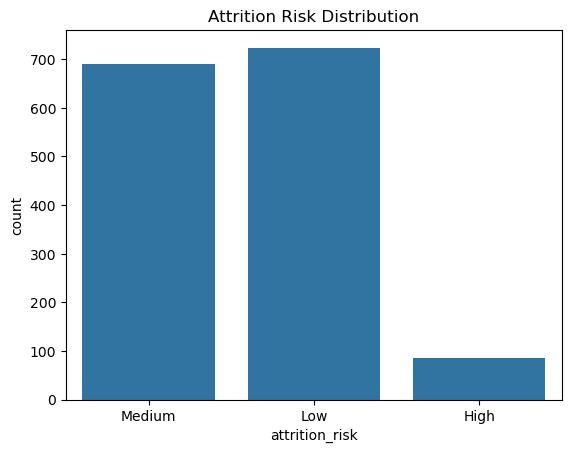

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='attrition_risk', data=data)

plt.title("Attrition Risk Distribution")
plt.show()

In [10]:
le = LabelEncoder()

for col in data.columns:
    if data[col].dtype == 'object':
        data[col] = le.fit_transform(data[col])

In [11]:
print(dict(zip(le.classes_, le.transform(le.classes_))))

{'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}


In [12]:
#The order depends on alphabetical order.

In [13]:
# Check class distribution
print(data['attrition_risk'].value_counts())

attrition_risk
1    724
2    691
0     85
Name: count, dtype: int64


In [14]:
print(data['attrition_risk'].value_counts(normalize=True)*100)

attrition_risk
1    48.266667
2    46.066667
0     5.666667
Name: proportion, dtype: float64


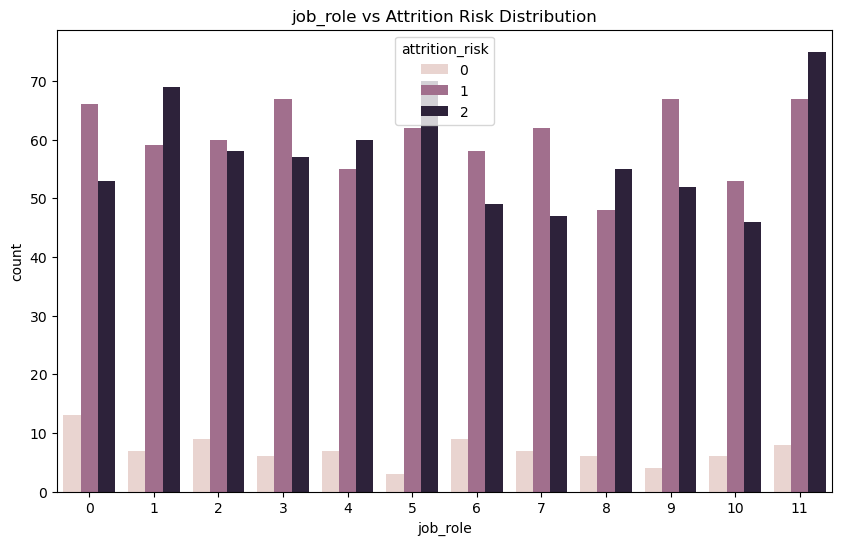

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
sns.countplot(x='job_role',hue='attrition_risk',data=data)

plt.title("job_role vs Attrition Risk Distribution")
plt.show()

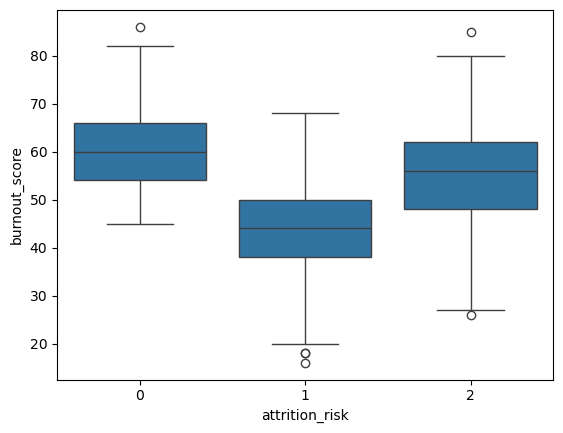

In [16]:
sns.boxplot(x='attrition_risk', y='burnout_score', data=data)
plt.show()

# feature selction 

In [17]:
X = data.drop("attrition_risk", axis=1)
y = data["attrition_risk"]

In [18]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)

X_resampled, y_resampled = sm.fit_resample(X, y)

In [19]:
pd.Series(y_resampled).value_counts()

attrition_risk
2    724
1    724
0    724
Name: count, dtype: int64

# train_test_split

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [21]:
#apply classification algorithms

In [22]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [23]:
dt = DecisionTreeClassifier()

dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

In [24]:
rf = RandomForestClassifier()

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

In [25]:
knn = KNeighborsClassifier()

knn.fit(X_train, y_train)

pred_knn = knn.predict(X_test)

In [26]:
#check accuracy of models

In [27]:
# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [28]:
print("Logistic Regression:", accuracy_score(y_test, pred_lr))

print("Decision Tree:", accuracy_score(y_test, pred_dt))

print("Random Forest:", accuracy_score(y_test, pred_rf))


print("KNN:", accuracy_score(y_test, pred_knn))



Logistic Regression: 0.8133333333333334
Decision Tree: 0.7866666666666666
Random Forest: 0.88
KNN: 0.61


In [29]:
print(classification_report(y_test, pred_rf))

              precision    recall  f1-score   support

           0       0.83      0.38      0.53        13
           1       0.91      0.90      0.90       141
           2       0.86      0.90      0.88       146

    accuracy                           0.88       300
   macro avg       0.87      0.73      0.77       300
weighted avg       0.88      0.88      0.88       300



In [30]:
cm = confusion_matrix(y_test, pred_rf)
cm


array([[  5,   0,   8],
       [  0, 127,  14],
       [  1,  13, 132]])

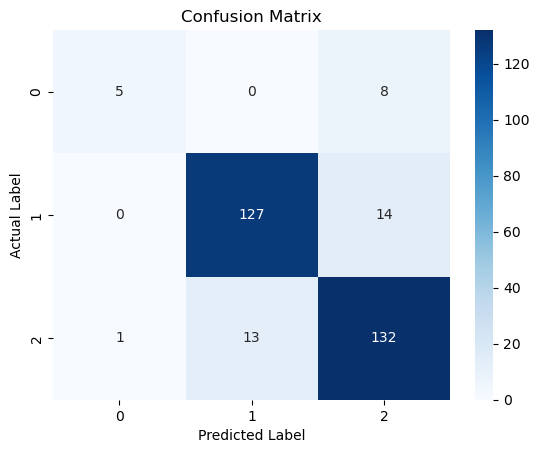

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

plt.show()

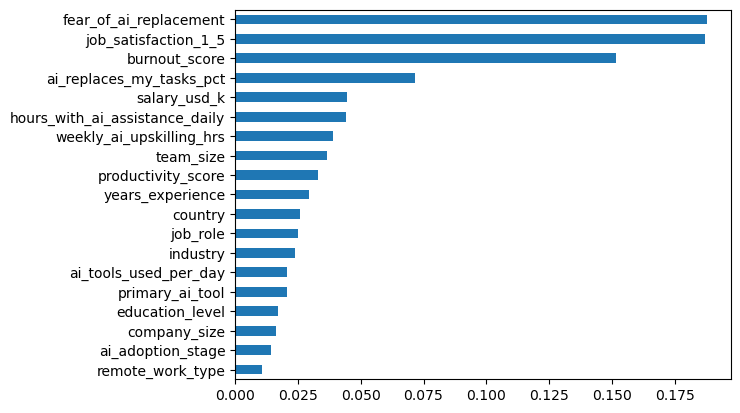

In [32]:
importance = rf.feature_importances_

feature_names = X.columns

pd.Series(importance, index=feature_names).sort_values().plot(kind='barh')

plt.show()

#  predictions

In [33]:
sample = X_test.iloc[0:10]

prediction = rf.predict(sample)

print("Predicted Attrition Risk:", prediction)

Predicted Attrition Risk: [2 2 2 0 2 1 1 2 2 2]


# Manual input predictions

In [34]:
new_employee = {
'job_role':2,
'years_experience':5,
'education_level':1,
'country':3,
'industry':1,
'company_size':2,
'remote_work_type':1,
'team_size':6,
'salary_usd_k':95,
'primary_ai_tool':3,
'ai_tools_used_per_day':4,
'hours_with_ai_assistance_daily':5,
'ai_replaces_my_tasks_pct':30,
'ai_adoption_stage':2,
'weekly_ai_upskilling_hrs':6,
'productivity_score':80,
'burnout_score':10,
'job_satisfaction_1_5':3,
'fear_of_ai_replacement':2
}

new_employee_df = pd.DataFrame([new_employee])

prediction = rf.predict(new_employee_df)

print(prediction)

[1]


In [35]:
new_employee1 = {
'job_role':2,
'years_experience':2,
'education_level':1,
'country':3,
'industry':1,
'company_size':2,
'remote_work_type':1,
'team_size':3,
'salary_usd_k':40,
'primary_ai_tool':3,
'ai_tools_used_per_day':6,
'hours_with_ai_assistance_daily':10,
'ai_replaces_my_tasks_pct':80,
'ai_adoption_stage':2,
'weekly_ai_upskilling_hrs':2,
'productivity_score':40,
'burnout_score':20,
'job_satisfaction_1_5':1,
'fear_of_ai_replacement':5
}

In [36]:
new_employee_df1 = pd.DataFrame([new_employee1])

prediction1 = rf.predict(new_employee_df1)

print(prediction1)

[2]


In [37]:
new_employee2 = {
'job_role':2,
'years_experience':5,
'education_level':0,
'country':3,
'industry':1,
'company_size':2,
'remote_work_type':1,
'team_size':5,
'salary_usd_k':70,
'primary_ai_tool':3,
'ai_tools_used_per_day':1,
'hours_with_ai_assistance_daily':6,
'ai_replaces_my_tasks_pct':40,
'ai_adoption_stage':2,
'weekly_ai_upskilling_hrs':4,
'productivity_score':20,
'burnout_score':100,
'job_satisfaction_1_5':1,
'fear_of_ai_replacement':3
}

In [38]:
new_employee_df2= pd.DataFrame([new_employee2])

prediction2 = rf.predict(new_employee_df2)

print(prediction2)

[2]


In [39]:
new_employee2 = {
'job_role':2,
'years_experience':8,
'education_level':0,
'country':2,
'industry':2,
'company_size':2,
'remote_work_type':1,
'team_size':48,
'salary_usd_k':120,
'primary_ai_tool':3,
'ai_tools_used_per_day':3,
'hours_with_ai_assistance_daily':6,
'ai_replaces_my_tasks_pct':73,
'ai_adoption_stage':2,
'weekly_ai_upskilling_hrs':3,
'productivity_score':44,
'burnout_score':65,
'job_satisfaction_1_5':3,
'fear_of_ai_replacement':0
}
new_employee2_df = pd.DataFrame([new_employee2])

prediction3 = rf.predict(new_employee2_df)

print(prediction3)

[0]
